## 1. Problem Framing

**Business question:** When we look across residents, is **high current risk** more strongly associated with **unresolved incident burden** or with **low service volume**?

- **Who cares:** program directors, case managers, and safety leads.
- **Why it matters:** if high risk is more tied to unresolved incidents (open-loop safety events), that points to better **resolution/follow-through** processes. If high risk is more tied to low service volume, that points to a potential **coverage gap** (not enough touchpoints for the highest-need cases).

**Approach type:** **Explanatory / relationship analysis** (not prediction). We use correlations and a simple regression to compare which signals are most strongly associated with the binary outcome `high_risk`.

**Target (`high_risk`):** 1 if `current_risk_level` is **High** or **Critical**, else 0.

**Main comparison signals** (constructed at the resident level):
- **Unresolved incidents:** `n_unresolved` = count of incident reports where `resolved == False`.
- **Low service volume:** `low_service_volume` = the **negative** of `service_volume` (so higher values mean fewer services), where `service_volume = n_sessions + n_home_visits`.

**Important note:** This is observational data. We describe **associations**, not guaranteed causation.


## 2. Data Acquisition, Preparation & Exploration

We build a **resident-level** dataset by joining:
- `residents.csv` (target + resident context)
- `incident_reports.csv` (incident counts and unresolved burden)
- `process_recordings.csv` (service/session volume)
- `home_visitations.csv` (home visit volume)

Key feature engineering (transparent and reproducible):
- **Unresolved incidents** = count where `resolved == False`
- **Incident burden** = total incidents, mean severity, follow-up required rate
- **Service volume** = number of sessions + number of home visits (+ optional duration)

We then compute simple correlations against `high_risk` to answer the business question directly.

In [6]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120


def find_project_root(marker_dir="lighthouse_csv_v7"):
    p = Path.cwd().resolve()
    for cand in [p] + list(p.parents):
        if (cand / marker_dir).exists():
            return cand
    raise FileNotFoundError(f"Could not find {marker_dir}/ starting from {p}")


PROJECT_ROOT = find_project_root("lighthouse_csv_v7")
DATA_DIR = PROJECT_ROOT / "lighthouse_csv_v7"

res = pd.read_csv(DATA_DIR / "residents.csv")
inc = pd.read_csv(DATA_DIR / "incident_reports.csv")
pr = pd.read_csv(DATA_DIR / "process_recordings.csv")
hv = pd.read_csv(DATA_DIR / "home_visitations.csv")

# basic typing
res["current_risk_level"] = res["current_risk_level"].astype(str)
inc["resolved"] = inc["resolved"].fillna(False).astype(bool)

# severity to numeric
sev_map = {"Low": 1, "Medium": 2, "High": 3, "Critical": 4}
if "severity" in inc.columns:
    inc["severity_num"] = inc["severity"].map(sev_map)

# target: high_risk
res["high_risk"] = res["current_risk_level"].isin(["High", "Critical"]).astype(int)

res[["resident_id", "current_risk_level", "high_risk"]].head()

,resident_id,current_risk_level,high_risk
0,1,High,1
1,2,Medium,0
2,3,Medium,0
3,4,Low,0
4,5,Low,0


In [7]:
# Aggregate incident burden to resident level
inc_agg = inc.groupby("resident_id").agg(
    n_incidents=("incident_id", "count"),
    n_unresolved=("resolved", lambda s: int((~s).sum())),
    unresolved_rate=("resolved", lambda s: float((~s).mean()) if len(s) else 0.0),
    mean_severity=("severity_num", "mean") if "severity_num" in inc.columns else ("incident_id", "size"),
    follow_up_required_rate=("follow_up_required", lambda s: pd.to_numeric(s, errors="coerce").fillna(False).astype(bool).mean())
    if "follow_up_required" in inc.columns
    else ("incident_id", "size"),
).reset_index()

# Service volume from process recordings (sessions)
pr_agg = pr.groupby("resident_id").agg(
    n_sessions=("recording_id", "count"),
    total_minutes=("session_duration_minutes", lambda s: float(pd.to_numeric(s, errors="coerce").fillna(0).sum()))
    if "session_duration_minutes" in pr.columns
    else ("recording_id", "count"),
    concerns_rate=("concerns_flagged", lambda s: pd.to_numeric(s, errors="coerce").fillna(False).astype(bool).mean())
    if "concerns_flagged" in pr.columns
    else ("recording_id", "count"),
    progress_rate=("progress_noted", lambda s: pd.to_numeric(s, errors="coerce").fillna(False).astype(bool).mean())
    if "progress_noted" in pr.columns
    else ("recording_id", "count"),
).reset_index()

# Home visit volume
hv_agg = hv.groupby("resident_id").agg(
    n_home_visits=("visitation_id", "count"),
    safety_concerns_rate=("safety_concerns_noted", lambda s: pd.to_numeric(s, errors="coerce").fillna(False).astype(bool).mean())
    if "safety_concerns_noted" in hv.columns
    else ("visitation_id", "count"),
    follow_up_needed_rate=("follow_up_needed", lambda s: pd.to_numeric(s, errors="coerce").fillna(False).astype(bool).mean())
    if "follow_up_needed" in hv.columns
    else ("visitation_id", "count"),
).reset_index()

# Merge to resident-level modeling table
m = res[["resident_id", "high_risk", "current_risk_level", "initial_risk_level", "has_special_needs", "family_parent_pwd", "family_solo_parent"]].copy()
for d in [inc_agg, pr_agg, hv_agg]:
    m = m.merge(d, on="resident_id", how="left")

# Fill missing aggregates as zeros
for c in [
    "n_incidents","n_unresolved","unresolved_rate","mean_severity","follow_up_required_rate",
    "n_sessions","total_minutes","concerns_rate","progress_rate",
    "n_home_visits","safety_concerns_rate","follow_up_needed_rate",
]:
    if c in m.columns:
        m[c] = pd.to_numeric(m[c], errors="coerce").fillna(0)

# Define service volume summary
m["service_volume"] = m["n_sessions"] + m["n_home_visits"]

# Low service volume (higher means fewer services)
m["low_service_volume"] = -m["service_volume"]

m.head()

,resident_id,high_risk,current_risk_level,initial_risk_level,has_special_needs,family_parent_pwd,family_solo_parent,n_incidents,n_unresolved,unresolved_rate,...,follow_up_required_rate,n_sessions,total_minutes,concerns_rate,progress_rate,n_home_visits,safety_concerns_rate,follow_up_needed_rate,service_volume,low_service_volume
0,1,1,High,Critical,True,False,False,4.0,1.0,0.25,...,0.250000,106,7360.0,0.235849,0.924528,54.0,0.166667,0.500000,160.0,-160.0
1,2,0,Medium,Medium,False,False,False,0.0,0.0,0.00,...,0.000000,51,3477.0,0.254902,0.921569,35.0,0.314286,0.485714,86.0,-86.0
2,3,0,Medium,Medium,False,False,False,2.0,2.0,1.00,...,1.000000,53,3681.0,0.188679,0.943396,26.0,0.423077,0.461538,79.0,-79.0
3,4,0,Low,High,False,False,False,3.0,0.0,0.00,...,0.333333,57,3967.0,0.210526,0.964912,9.0,0.333333,0.333333,66.0,-66.0
4,5,0,Low,Medium,False,False,False,2.0,1.0,0.50,...,1.000000,18,1181.0,0.166667,1.000000,11.0,0.181818,0.272727,29.0,-29.0


Residents: 60
High risk rate: 0.1


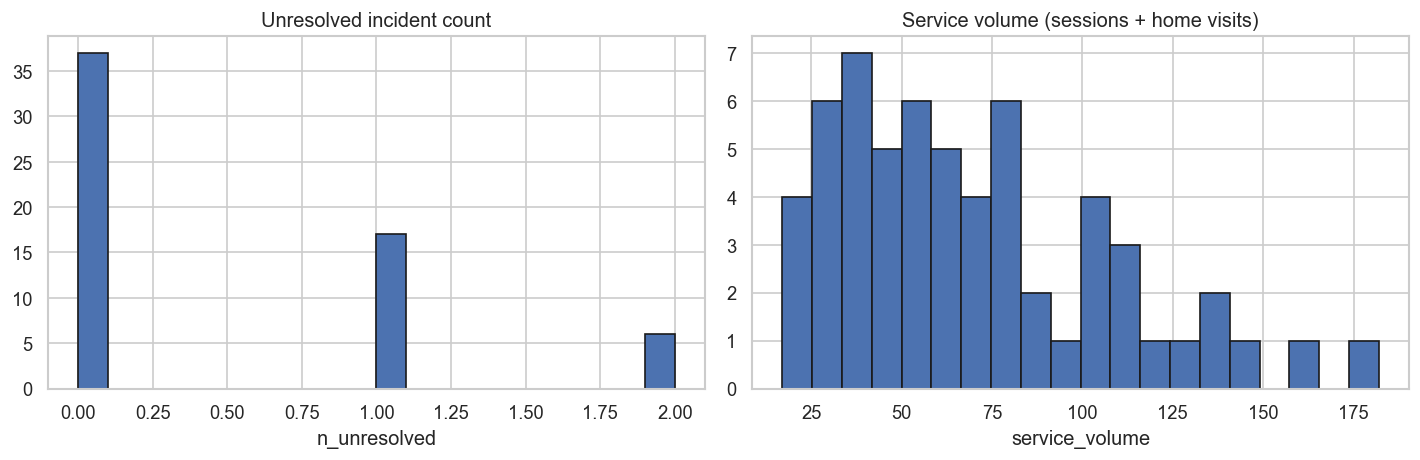

           n_unresolved  n_incidents  service_volume  low_service_volume  \
high_risk                                                                  
0              0.407407     1.462963       63.314815          -63.314815   
1              1.166667     3.500000      122.833333         -122.833333   

           n_sessions  n_home_visits  
high_risk                             
0           42.611111      20.703704  
1           86.333333      36.500000  


In [8]:
# Quick exploration: distributions and group differences
print('Residents:', len(m))
print('High risk rate:', m['high_risk'].mean())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(m['n_unresolved'], bins=20, edgecolor='k')
ax[0].set_title('Unresolved incident count')
ax[0].set_xlabel('n_unresolved')

ax[1].hist(m['service_volume'], bins=20, edgecolor='k')
ax[1].set_title('Service volume (sessions + home visits)')
ax[1].set_xlabel('service_volume')
plt.tight_layout()
plt.show()

# Compare means by risk group
summary = m.groupby('high_risk')[['n_unresolved','n_incidents','service_volume','low_service_volume','n_sessions','n_home_visits']].mean()
print(summary)


## Correlation analysis (direct answer to the business question)

Because `high_risk` is binary, we use:
- **Point-biserial correlation** between `high_risk` and each numeric feature (equivalent to Pearson with a binary variable).

We compare:
- `n_unresolved` (unresolved incidents)
- `low_service_volume` (defined as `-service_volume`, so **higher** means **fewer** services)

Whichever has the **larger absolute correlation** is more strongly associated with high risk in this dataset.

                feature  corr_with_high_risk
             n_sessions             0.507126
          total_minutes             0.506351
         service_volume             0.479471
     low_service_volume            -0.479471
            n_incidents             0.444649
           n_unresolved             0.339656
          n_home_visits             0.317765
          mean_severity             0.169216
        unresolved_rate             0.145783
follow_up_required_rate             0.136405
  follow_up_needed_rate             0.112044
   safety_concerns_rate             0.097159
          progress_rate            -0.090964
          concerns_rate             0.009577


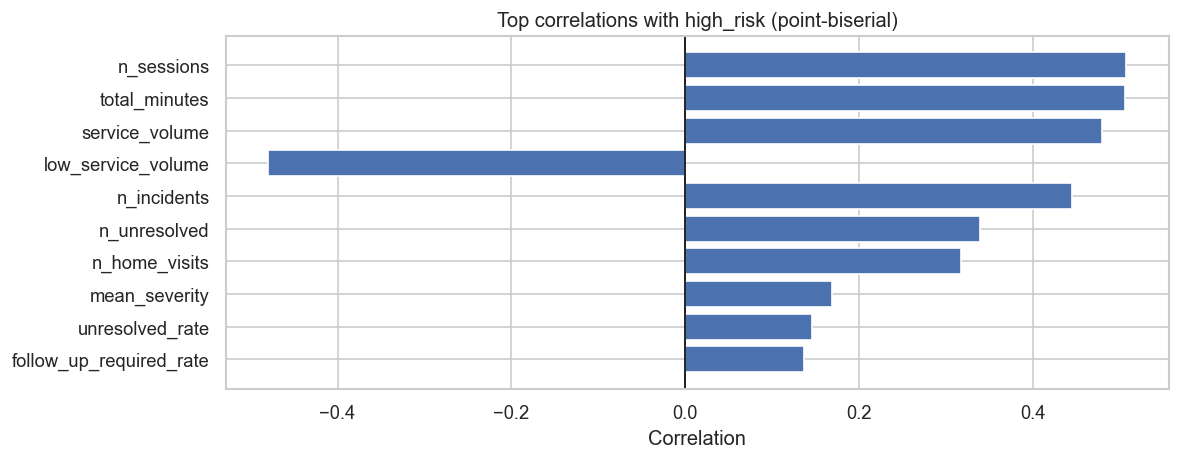

corr(high_risk, n_unresolved)= 0.3396559115042038
corr(high_risk, low_service_volume)= -0.47947053927609123


In [9]:
def point_biserial_corr(y01, x):
    y = pd.to_numeric(y01, errors='coerce')
    x = pd.to_numeric(x, errors='coerce')
    df = pd.DataFrame({'y': y, 'x': x}).dropna()
    if df['y'].nunique() < 2 or len(df) < 3:
        return np.nan
    return float(df['y'].corr(df['x']))

candidates = [
    'n_unresolved',
    'n_incidents',
    'unresolved_rate',
    'mean_severity',
    'follow_up_required_rate',
    'service_volume',
    'low_service_volume',
    'n_sessions',
    'n_home_visits',
    'total_minutes',
    'concerns_rate',
    'progress_rate',
    'safety_concerns_rate',
    'follow_up_needed_rate',
]

cors = []
for c in candidates:
    if c in m.columns:
        cors.append((c, point_biserial_corr(m['high_risk'], m[c])))

corr_df = pd.DataFrame(cors, columns=['feature','corr_with_high_risk']).sort_values('corr_with_high_risk', key=lambda s: s.abs(), ascending=False)
print(corr_df.to_string(index=False))

# Visualize top correlations
top = corr_df.head(10).copy()
plt.figure(figsize=(10, 4))
plt.barh(top['feature'][::-1], top['corr_with_high_risk'][::-1])
plt.axvline(0, color='black', linewidth=1)
plt.title('Top correlations with high_risk (point-biserial)')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

print('corr(high_risk, n_unresolved)=', float(corr_df.loc[corr_df.feature=='n_unresolved','corr_with_high_risk'].iloc[0]) if (corr_df.feature=='n_unresolved').any() else None)
print('corr(high_risk, low_service_volume)=', float(corr_df.loc[corr_df.feature=='low_service_volume','corr_with_high_risk'].iloc[0]) if (corr_df.feature=='low_service_volume').any() else None)


## 3. Modeling & Feature Selection (optional context)

To complement correlations, we fit a simple **Linear Probability Model (OLS)** with `high_risk` as the outcome.

Why include this?
- Correlations answer “what moves together?”
- The regression answers “which signal is stronger **after controlling for the other**?”

We keep it simple and focus on the two key signals plus a few basic controls.

In [10]:
# Simple LPM with the two competing signals
model_df = m[[
    'high_risk',
    'n_unresolved',
    'low_service_volume',
    'mean_severity',
    'n_incidents',
    'has_special_needs',
    'family_parent_pwd',
    'family_solo_parent',
]].copy()

for c in ['has_special_needs','family_parent_pwd','family_solo_parent']:
    if c in model_df.columns:
        model_df[c] = pd.to_numeric(model_df[c], errors='coerce').fillna(0).astype(int)

model_df = model_df.fillna(0)

y = model_df['high_risk']
X = model_df.drop(columns=['high_risk'])
X = sm.add_constant(X, has_constant='add')

lpm = sm.OLS(y, X).fit()
print(lpm.summary())

# Show which of the two key signals has the larger absolute t-stat in the multivariable context
key = lpm.tvalues[['n_unresolved','low_service_volume']].sort_values(key=lambda s: s.abs(), ascending=False)
print('\nKey signals t-stats (higher |t| = stronger):')
print(key)


                            OLS Regression Results                            
Dep. Variable:              high_risk   R-squared:                       0.372
Model:                            OLS   Adj. R-squared:                  0.287
Method:                 Least Squares   F-statistic:                     4.395
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           0.000680
Time:                        14:48:31   Log-Likelihood:                 1.0438
No. Observations:                  60   AIC:                             13.91
Df Residuals:                      52   BIC:                             30.67
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.1432      0

## 4. Evaluation & Interpretation

Because this is **explanatory**, the “evaluation” is whether the relationships are:
- **consistent** (correlation and regression broadly agree),
- **plausible** (they make sense operationally), and
- **useful** (they suggest where staff attention should go).

We interpret results in plain language:
- If `n_unresolved` is more strongly linked to `high_risk`, that supports the idea that **resolution and follow-up** are critical.
- If `low_service_volume` is more strongly linked, that supports the idea that **coverage gaps** (fewer touchpoints) are associated with high risk.

One more caution: even if `low_service_volume` is strongly linked, that does not prove causation — it can also reflect that staff prioritize services toward high-risk cases (which would produce the opposite pattern).

## 5. Causal and Relationship Analysis

### What would it mean if unresolved incidents are the stronger signal?
- It suggests that the **open-loop** items (incidents that are not resolved) are a better “warning light” than how many touchpoints happened.
- Operationally: track **resolution rate, time-to-resolution, and follow-up completion**, not just activity counts.

### What would it mean if low service volume is the stronger signal?
- It would suggest a potential **coverage gap**: residents with fewer sessions/visits are more likely to be high risk.
- If true, the organization might need minimum-touchpoint standards, escalation rules, or staffing adjustments.

### Why we still can’t claim causality from this notebook alone
- **Reverse causality is likely** in real operations: when a resident is high risk, staff often increase services (which would make *high* service volume correlate with high risk).
- Incident recording and “resolved” status can vary by staff/policy.
- Timing matters: services and incidents could be recorded after risk changes.

A stronger causal design would use time ordering (features measured before the risk assessment), matching comparable residents, or controlled workflow interventions.

## 6. Deployment Notes

This analysis is meant to drive a **case-review dashboard**.

Recommended dashboard widgets powered by these features:
- **High-risk list** with columns: `n_unresolved`, `unresolved_rate`, `mean_severity`, `service_volume`, `n_sessions`, `n_home_visits`
- **Alerts** when `n_unresolved` exceeds a threshold or when `unresolved_rate` stays high for multiple weeks.

If you want, we can add an export cell that writes the resident-level table to `artifacts/high_risk_signals.csv` for the web app to consume.